# EDA

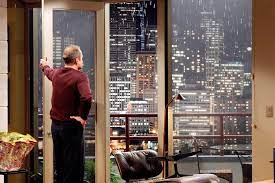

In [8]:
import warnings

import matplotlib.pyplot as plt
import pandas as pd

warnings.filterwarnings("ignore")

plt.rcParams.update(
    {"figure.figsize": (8, 5), "axes.facecolor": "white", "axes.edgecolor": "black"}
)
plt.rcParams["figure.facecolor"] = "w"
pd.plotting.register_matplotlib_converters()
pd.set_option("display.float_format", lambda x: "%.3f" % x)

In [12]:
df_details = pd.read_csv("data/king_county_house_details_202606171339.csv")
df_sales = pd.read_csv("data/king_county_house_sales_202606171339.csv")

In [29]:
df_details.head(5)
#print(df_details.nunique())

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,1000102,6.000,3.000,2400.000,9373.000,2.000,NaN,0.000,3,7,2400.000,0.000,1991,0.000,98002,47.326,-122.214,2060.000,7316.000
1,100100050,3.000,1.000,1320.000,11090.000,1.000,0.000,0.000,3,7,1320.000,0.000,1955,0.000,98155,47.775,-122.304,1320.000,8319.000
2,1001200035,3.000,1.000,1350.000,7973.000,1.500,NaN,0.000,3,7,1350.000,0.000,1954,0.000,98188,47.432,-122.292,1310.000,7491.000
3,1001200050,4.000,1.500,1260.000,7248.000,1.500,NaN,0.000,5,7,1260.000,0.000,1955,NaN,98188,47.433,-122.292,1300.000,7732.000
4,1003000175,3.000,1.000,980.000,7606.000,1.000,0.000,0.000,3,7,980.000,0.000,1954,0.000,98188,47.436,-122.290,980.000,8125.000


In [ ]:
df_details.info()
df_details.describe()

# NaNs in waterfront, view, sqft_basement, yr_renovated
# all columns are quantitative data 
# no duplicates
# unsure if floors, bedrooms, bathrooms, waterfront, view is float
# sqft_lot and yr_renovated might have outliers — need to check if year renovated is realistic at all 
# no missing column names or naming problems
# why does long have negative data? probably shouldnt, except if basement 

<class 'pandas.DataFrame'>
RangeIndex: 21420 entries, 0 to 21419
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21420 non-null  int64  
 1   bedrooms       21420 non-null  float64
 2   bathrooms      21420 non-null  float64
 3   sqft_living    21420 non-null  float64
 4   sqft_lot       21420 non-null  float64
 5   floors         21420 non-null  float64
 6   waterfront     19060 non-null  float64
 7   view           21357 non-null  float64
 8   condition      21420 non-null  int64  
 9   grade          21420 non-null  int64  
 10  sqft_above     21420 non-null  float64
 11  sqft_basement  20969 non-null  float64
 12  yr_built       21420 non-null  int64  
 13  yr_renovated   17609 non-null  float64
 14  zipcode        21420 non-null  int64  
 15  lat            21420 non-null  float64
 16  long           21420 non-null  float64
 17  sqft_living15  21420 non-null  float64
 18  sqft_lot15     21

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,21420.000,21420.000,21420.000,21420.000,21420.000,21420.000,19060.000,21357.000,21420.000,21420.000,21420.000,20969.000,21420.000,17609.000,21420.000,21420.000,21420.000,21420.000,21420.000
mean,4580939869.158,3.374,2.118,2083.133,15128.038,1.496,0.008,0.235,3.411,7.663,1791.170,292.087,1971.093,838.806,98077.874,47.560,-122.214,1988.384,12775.718
std,2876761172.448,0.925,0.769,918.808,41530.797,0.540,0.087,0.766,0.650,1.172,828.693,442.696,29.387,4005.127,53.477,0.139,0.141,685.537,27345.622
min,1000102.000,1.000,0.500,370.000,520.000,1.000,0.000,0.000,1.000,3.000,370.000,0.000,1900.000,0.000,98001.000,47.156,-122.519,399.000,651.000
25%,2123537386.750,3.000,1.750,1430.000,5040.000,1.000,0.000,0.000,3.000,7.000,1200.000,0.000,1952.000,0.000,98033.000,47.471,-122.328,1490.000,5100.000
50%,3904921185.000,3.000,2.250,1920.000,7614.000,1.500,0.000,0.000,3.000,7.000,1560.000,0.000,1975.000,0.000,98065.000,47.572,-122.230,1840.000,7620.000
75%,7308900186.250,4.000,2.500,2550.000,10690.500,2.000,0.000,0.000,4.000,8.000,2220.000,560.000,1997.000,0.000,98117.000,47.678,-122.125,2370.000,10086.250
max,9900000190.000,33.000,8.000,13540.000,1651359.000,3.500,1.000,4.000,5.000,13.000,9410.000,4820.000,2015.000,20150.000,98199.000,47.778,-121.315,6210.000,871200.000


In [40]:

df_sales.head(5)
print(df_sales.nunique())



date          372
price        3622
house_id    21420
id          21597
dtype: int64


In [ ]:
df_sales.info()
df_sales.describe()

# no NaNs
# some dates, prices and houses have repetitions but for diffrent ids
# all columns are quantitative data 
# date should be date format
# no full duplicate rows
# no missing column names or naming problems
# why does long have negative data? probably shouldnt, except if basement 

<class 'pandas.DataFrame'>
RangeIndex: 21597 entries, 0 to 21596
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   date      21597 non-null  str    
 1   price     21597 non-null  float64
 2   house_id  21597 non-null  int64  
 3   id        21597 non-null  int64  
dtypes: float64(1), int64(2), str(1)
memory usage: 675.0 KB


,price,house_id,id
count,21597.000,21597.000,21597.000
mean,540296.574,4580474287.771,10799.000
std,367368.140,2876735715.748,6234.661
min,78000.000,1000102.000,1.000
25%,322000.000,2123049175.000,5400.000
50%,450000.000,3904930410.000,10799.000
75%,645000.000,7308900490.000,16198.000
max,7700000.000,9900000190.000,21597.000


In [ ]:
x_col = "sqft_living"
y_col = "grade"

plt.scatter(df_details[x_col], df_details[y_col], alpha=0.3, s=10)
plt.xlabel(x_col)
plt.ylabel(y_col)
plt.title(f"{x_col} vs {y_col}")
plt.show()